In [1]:
using Pkg
Pkg.activate(@__DIR__)
Pkg.instantiate()
using Revise

using Random
using Statistics
using Adapt
using Functors
using Flux
using Onion
using RandomFeatureMaps
using Zygote

Pkg.develop(path=joinpath(@__DIR__, ".."))
using Flowfusion
const FF = Flowfusion

include(joinpath(@__DIR__, "prob_model.jl"))
include(joinpath(@__DIR__, "helper_funcs.jl"))


  Activating project at `~/dev/Flowfusion.jl/editflow_code`
   Resolving package versions...
  No Changes to `~/dev/Flowfusion.jl/editflow_code/Project.toml`
  No Changes to `~/dev/Flowfusion.jl/editflow_code/Manifest.toml`


plot_len_dist (generic function with 1 method)

In [2]:
import CUDA

# Device helpers
const _gpu_enabled = try
    CUDA.has_cuda()
catch
    false
end

to_dev(x) = _gpu_enabled ? Adapt.adapt(CUDA.CuArray, x) : x
to_cpu(x) = _gpu_enabled ? Adapt.adapt(Array, x) : x
# move x to the same device type as y (Array or CuArray)
to_same_device(x, y) = (_gpu_enabled && (y isa CUDA.CuArray)) ? Adapt.adapt(CUDA.CuArray, x) : Adapt.adapt(Array, x)


to_same_device (generic function with 1 method)

In [3]:
# Minibatch builder (uses true PM)
function make_minibatch(B::Int, P::FF.EditFlow; rng=Random.default_rng())
    K = P.k
    x0s = Vector{FF.DiscreteState}(undef, B)
    x1s = Vector{FF.DiscreteState}(undef, B)
    for b in 1:B
        # x1 from true PM
        seq1 = sample(PM; rng=rng)
        @assert all(1 .<= seq1 .<= K)
        x1s[b] = FF.DiscreteState(K, seq1)
        # x0: uniform tokens with random length in 1:10 (no BOS in x0)
        L0 = rand(rng, 1:10)
        seq0 = rand(rng, 1:K, L0)
        x0s[b] = FF.DiscreteState(K, seq0)
    end
    ts = rand(rng, Float32, B)
    return x0s, x1s, ts
end


make_minibatch (generic function with 1 method)

In [4]:
# Model definition
struct EditFlowModel{L}
    layers::L
end
Flux.@layer EditFlowModel

function EditFlowModel(; d=128, num_heads=8, nlayers=6, rff_dim=128, cond_dim=128, K::Int)
    embedding   = Flux.Embedding(K + 2 => d)
    time_embed  = Flux.Chain(RandomFourierFeatures(1 => rff_dim, 1.0f0), Dense(rff_dim => cond_dim))
    blocks      = [Onion.AdaTransformerBlock(d, cond_dim, num_heads) for _ in 1:nlayers]
    head_combined = Dense(d => 2K + 1, bias=false)
    rope        = RoPE(d ÷ num_heads, 4096)
    return EditFlowModel((; embedding, time_embed, blocks, head_combined, rope, K))
end


EditFlowModel

In [5]:
# Forward pass
function (model::EditFlowModel)(t, Xt_ms)
    m = model.layers
    X = FF.tensor(Xt_ms)
    X = ndims(X) == 1 ? reshape(X, :, 1) : X
    L, B = size(X)

    pmask = Zygote.@ignore FF.getlmask(Xt_ms)
    Xp = X .+ 1
    H = m.embedding(Xp)

    t = ndims(t) == 0 ? fill(Float32(t), B) : Float32.(t)
    cond = m.time_embed(reshape(t, 1, B))

    cond  = to_same_device(cond, H)
    pmask = Zygote.@ignore to_same_device(pmask, H)
    rope  = Zygote.@ignore to_same_device(m.rope[1:L], H)

    for blk in m.blocks
        H = blk(H; cond, rope, kpad_mask=pmask)
    end
    return m.head_combined(H)
end


In [6]:
# Training (GPU if available)
function train_editflow!(P::FF.EditFlow,
                        model;
                        epochs::Int=1,
                        steps_per_epoch::Int=100,
                        batch_size::Int=64,
                        lr::Float32=1f-2,
                        seed::Int=42,
                        print_every::Int=25)

    rng = Random.MersenneTwister(seed)
    Random.seed!(seed)

    # Move model to device (GPU if available)
    model = Functors.fmap(to_dev, model)
    opt_state = Flux.setup(Flux.Adam(lr), model)

    for epoch in 1:epochs
        for step in 1:steps_per_epoch

            # 1) Minibatch Sampling
            x0s, x1s, ts = make_minibatch(batch_size, P; rng=rng)

            # 2) Align and batch
            Z0, Z1 = FF.align_and_batch(P, x0s, x1s)

            # 3) Interpolate
            Zt, Xt = FF.interpolate_Z_elementwise(P, Z0, Z1, ts)

            # 4) Prepend BOS
            bos = P.bos_token
            Zt = vcat(fill(bos, 1, batch_size), Zt)
            Xt = vcat(fill(bos, 1, batch_size), Xt)
            Z1 = vcat(fill(bos, 1, batch_size), Z1)
            
            # 5) Masks and multipliers
            transition_mask = FF.transition_mask_from_Xt(P, Xt)
            edit_multiplier = FF.remaining_edits(P, Zt, Z1, Xt)
            @assert size(transition_mask) == size(edit_multiplier)

            # 6) Scheduler scaling
            den = 1f0 .- P.κ.(ts)
            den = max.(den, 1f-3)
            scheduler_scaling = P.dκ.(ts) ./ den

            # 7) Masked state
            lmask = Xt .!= P.padding_token
            cmask = trues(size(lmask))
            Xt_ms = FF.MaskedState(FF.DiscreteState(P.k, Xt), cmask, lmask)

            ts_d    = to_dev(ts)
            Xt_ms_d = to_dev(Xt_ms)
            Tmask_d = to_dev(transition_mask)
            Emult_d = to_dev(edit_multiplier)
            sched_d = to_dev(reshape(Float32.(scheduler_scaling), 1, 1, :))

            # 8) Forward + loss + update
            loss, grad = Flux.withgradient(model) do m
                M = m(ts_d, Xt_ms_d)
                l = FF.edit_loss(P, M, Tmask_d, Emult_d, sched_d; eps=1f-8)
                if isnan(l)
                    println("Maximum element of M: ", maximum(M))
                end
                l
            end
            Flux.update!(opt_state, model, grad[1])

            if step % print_every == 0
                @info "train" epoch step loss=Float32(loss)
            end
        end
    end

    return Functors.fmap(to_cpu, model)
end


train_editflow! (generic function with 1 method)

In [8]:
# Init process and model
K = PM.K
P = FF.EditFlow(K; bos_token=0, impl="positionwise")
model = EditFlowModel(; d=128, num_heads=8, nlayers=4, rff_dim=128, cond_dim=128, K=K)
nothing

In [ ]:
model = train_editflow!(P, model; epochs=50, steps_per_epoch=150, batch_size=256, lr=1f-4)


┌ Info: train
│   epoch = 1
│   step = 25
└   loss = 83.736786f0
┌ Info: train
│   epoch = 1
│   step = 50
└   loss = 64.495285f0
┌ Info: train
│   epoch = 1
│   step = 75
└   loss = 58.378933f0
┌ Info: train
│   epoch = 1
│   step = 100
└   loss = 57.44657f0
┌ Info: train
│   epoch = 1
│   step = 125
└   loss = 53.10153f0
┌ Info: train
│   epoch = 1
│   step = 150
└   loss = 52.092472f0
┌ Info: train
│   epoch = 2
│   step = 25
└   loss = 51.066406f0
┌ Info: train
│   epoch = 2
│   step = 50
└   loss = 50.10228f0
┌ Info: train
│   epoch = 2
│   step = 75
└   loss = 52.646454f0
┌ Info: train
│   epoch = 2
│   step = 100
└   loss = 48.27961f0
┌ Info: train
│   epoch = 2
│   step = 125
└   loss = 47.068417f0
┌ Info: train
│   epoch = 2
│   step = 150
└   loss = 47.148155f0
┌ Info: train
│   epoch = 3
│   step = 25
└   loss = 47.38747f0
┌ Info: train
│   epoch = 3
│   step = 50
└   loss = 48.832336f0
┌ Info: train
│   epoch = 3
│   step = 75
└   loss = 46.620193f0
┌ Info: train
│   epoch 

EditFlowModel(
  Embedding(22 => 128),                 # 2_816 parameters
  Chain(
    RandomFourierFeatures{Float32, Matrix{Float32}}(Float32[1.7281183 -8.28652 … 0.6994802 8.02288]),
    Dense(128 => 128),                  # 16_512 parameters
  ),
  [
    TransformerBlock(
      Attention(
        Dense(128 => 128; bias=false),  # 16_384 parameters
        Dense(128 => 128; bias=false),  # 16_384 parameters
        Dense(128 => 128; bias=false),  # 16_384 parameters
        Dense(128 => 128; bias=false),  # 16_384 parameters
        identity,
        identity,
        Onion.var"#32#34"(),
        16,
        16,
        8,
        8,
      ),
      StarGLU(
        Dense(128 => 512; bias=false),  # 65_536 parameters
        Dense(512 => 128; bias=false),  # 65_536 parameters
        Dense(128 => 512; bias=false),  # 65_536 parameters
        NNlib.swish,
      ),
      AdaLN(
        Onion.LayerNorm{Vector{Float32}, Vector{Float32}, Float32}(Float32[0.95842546, 0.98741066, 0.98946583

In [15]:
rng = Random.MersenneTwister(123023)

MersenneTwister(123023)

In [ ]:
# Sampling and Levenshtein plot
using Random
n = 1000
# 100 model samples (final states → strings)
model_samples_any = sample_gen_n(P, model; n=n, ts=0f0:0.01f0:1f0, rng=rng)
model_final_states = map(final_state_from_gen, model_samples_any)
model_strings = [state_to_PM_string(P, s) for s in model_final_states]




LoadError: ParseError:
[90m# Error @ [0;0m]8;;file:///home/theodor/dev/Flowfusion.jl/editflow_code/In[16]#10:59\[90mIn[16]:10:59[0;0m]8;;\
# Build training strings from PM parents (the data PM was built on)
train_states = [FF.DiscreteState(P.k, sample(PM; rng=rng))[48;2;120;70;70m[0;0m) for i in 1:100]
[90m#                                                         └ ── [0;0m[91mExpected `]`[0;0m

In [ ]:
# Build training strings from PM parents (the data PM was built on)
train_states = [FF.DiscreteState(P.k, sample(PM; rng=rng)) for i in 1:100]
train_strings = [state_to_PM_string(P, s) for s in train_states]

# Independent validation strings sampled from PM
val_states = [FF.DiscreteState(P.k, sample(PM; rng=rng)) for i in 1:n]
val_strings = [state_to_PM_string(P, s) for s in val_states]
#val_strings = [s for s in val_strings if !(s in train_strings)]

# Plot normalized Levenshtein vs. training set (distinct val/train)
plt = plot_lev_dist("model_vs_true", val_strings, model_strings, train_strings; title="Model vs True (normalized Levenshtein)")
display(plt)

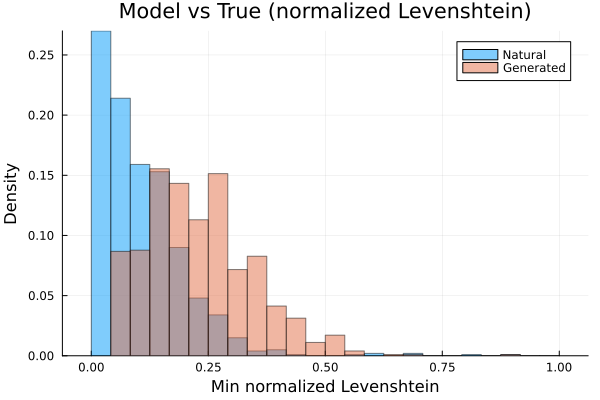

In [11]:
model_strings_bos = [">" * state_to_PM_string(P, s) for s in model_final_states]
plt = plot_lev_dist("model_vs_true", val_strings, model_strings_bos, train_strings; title="Model vs True (normalized Levenshtein)")
display(plt)


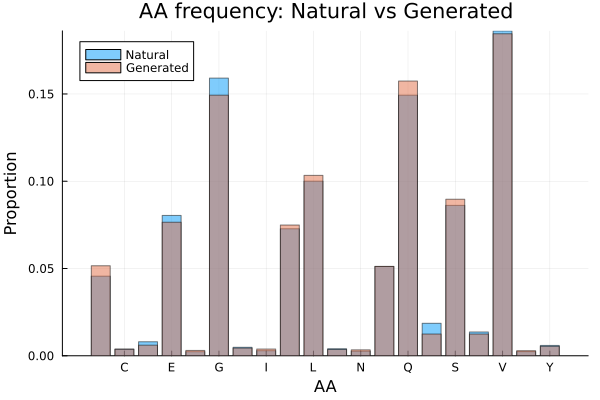

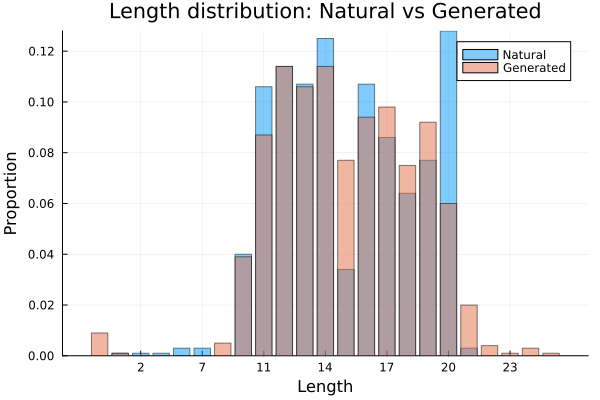

In [12]:

pAA = plot_AA_dist("model_vs_true_AA", val_strings, model_strings; title="AA frequency: Natural vs Generated")
display(pAA)

pLen = plot_len_dist("model_vs_true_len", val_strings, model_strings; title="Length distribution: Natural vs Generated")
display(pLen)


In [13]:
println("Natural 'A' frequency: ", (isdefined(Main, :val_strings) ? sum(count(==('A'), s) for s in val_strings) / sum(length.(val_strings)) : sum(count(==('A'), s) for s in val_strings) / sum(length.(val_strings))))

Natural 'A' frequency: 0.04562383612662942


In [14]:
println("Natural 'A' frequency: ", (isdefined(Main, :model_strings) ? sum(count(==('A'), s) for s in model_strings) / sum(length.(model_strings)) : sum(count(==('A'), s) for s in model_strings) / sum(length.(model_strings))))

Natural 'A' frequency: 0.051578034296390206
